In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet(r"D:\05_PROJECTS\supplychain\Supply Chain Intelligence Platform for Forecasting, Logistics, and Operational Analytics\cleaned_supplychain.parquet")

In [3]:
df.head()
pd.set_option('display.max_columns', None)
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Fname,Customer Id,Customer Lname,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Name,Product Price,shipping date (DateOrders),Shipping Mode,Order Year,Order Month,Order Quarter,Order Week,Shipping Delay,On_Time_Delivery,Profit Margin
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,Cally,20755,Holloway,Consumer,PR,5365 Noble Nectar Island,725.0,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.110000,0.04,180517,327.750000,0.29,1,327.750000,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,1360,Smart watch,327.750000,2018-02-03 22:56:00,Standard Class,2018,1,1,5,-1,1,27.841342
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,Irene,19492,Luna,Consumer,PR,2679 Rustic Loop,725.0,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.389999,0.05,179254,327.750000,-0.80,1,327.750000,311.359985,-249.089996,South Asia,Rajastán,PENDING,1360,Smart watch,327.750000,2018-01-18 12:27:00,Standard Class,2018,1,1,2,1,0,-75.999999
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,Gillian,19491,Maldonado,Consumer,CA,8510 Round Bear Gate,95125.0,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,2018-01-13 12:06:00,75938,1360,18.030001,0.06,179253,327.750000,-0.80,1,327.750000,309.720001,-247.779999,South Asia,Rajastán,CLOSED,1360,Smart watch,327.750000,2018-01-17 12:06:00,Standard Class,2018,1,1,2,0,1,-75.600305
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,Tana,19490,Tate,Home Office,CA,3200 Amber Bend,90027.0,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,2018-01-13 11:45:00,75937,1360,22.940001,0.07,179252,327.750000,0.08,1,327.750000,304.809998,22.860001,Oceania,Queensland,COMPLETE,1360,Smart watch,327.750000,2018-01-16 11:45:00,Standard Class,2018,1,1,2,-1,1,6.974829
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,Orli,19489,Hendricks,Corporate,PR,8671 Iron Anchor Corners,725.0,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,2018-01-13 11:24:00,75936,1360,29.500000,0.09,179251,327.750000,0.45,1,327.750000,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,1360,Smart watch,327.750000,2018-01-15 11:24:00,Standard Class,2018,1,1,2,-2,1,40.948896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,Fishing,Brooklyn,EE. UU.,Maria,1005,Peterson,Home Office,NY,1322 Broad Glade,11207.0,Fan Shop,40.640930,-73.942711,Pacific Asia,Shanghái,China,1005,2016-01-16 03:40:00,26043,1004,0.000000,0.00,65177,399.980011,0.10,1,399.980011,399.980011,40.000000,Eastern Asia,Shanghái,CLOSED,1004,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,2016-01-20 03:40:00,Standard Class,2016,1,1,2,0,1,10.000500
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,Fishing,Bakersfield,EE. UU.,Ronald,9141,Clark,Corporate,CA,7330 Broad Apple Moor,93304.0,Fan Shop,35.362545,-119.018700,Pacific Asia,Hirakata,Japón,9141,2016-01-16 01:34:00,26037,1004,4.000000,0.01,65161,399.980011,-1.55,1,399.980011,395.980011,-613.770019,Eastern Asia,Osaka,COM

## "The profit margins in the table above represent individual product orders, not the aggregate total." 

# Pricing Strategy

In [4]:
avg_discount = df['Order Item Discount Rate'].mean()
print('Average Discount rate: ',round(avg_discount,3)*100,'%')

Average Discount rate:  10.2 %


In [5]:
top_discounted_products = df.groupby('Product Name')[
    'Order Item Discount Rate'
].mean().reset_index()

top_discounted_products = top_discounted_products.sort_values(
    by='Order Item Discount Rate',
    ascending=False
)

top_discounted_products.head(10)

,Product Name,Order Item Discount Rate
4,Bowflex SelectTech 1090 Dumbbells,0.138000
77,SOLE E35 Elliptical,0.120000
19,Diamondback Boys' Insight 24 Performance Hybr,0.118966
45,LIJA Women's Mid-Length Panel Golf Shorts,0.116438
8,Brooks Women's Ghost 6 Running Shoe,0.114697
42,LIJA Women's Argyle Golf Polo,0.113333
92,The North Face Women's Recon Backpack,0.111404
27,Fitbit The One Wireless Activity & Sleep Trac,0.110806
117,insta-bed Neverflat Air Mattress,0.110000
62,Nike Men's Free TR 5.0 TB Training Shoe,0.109412


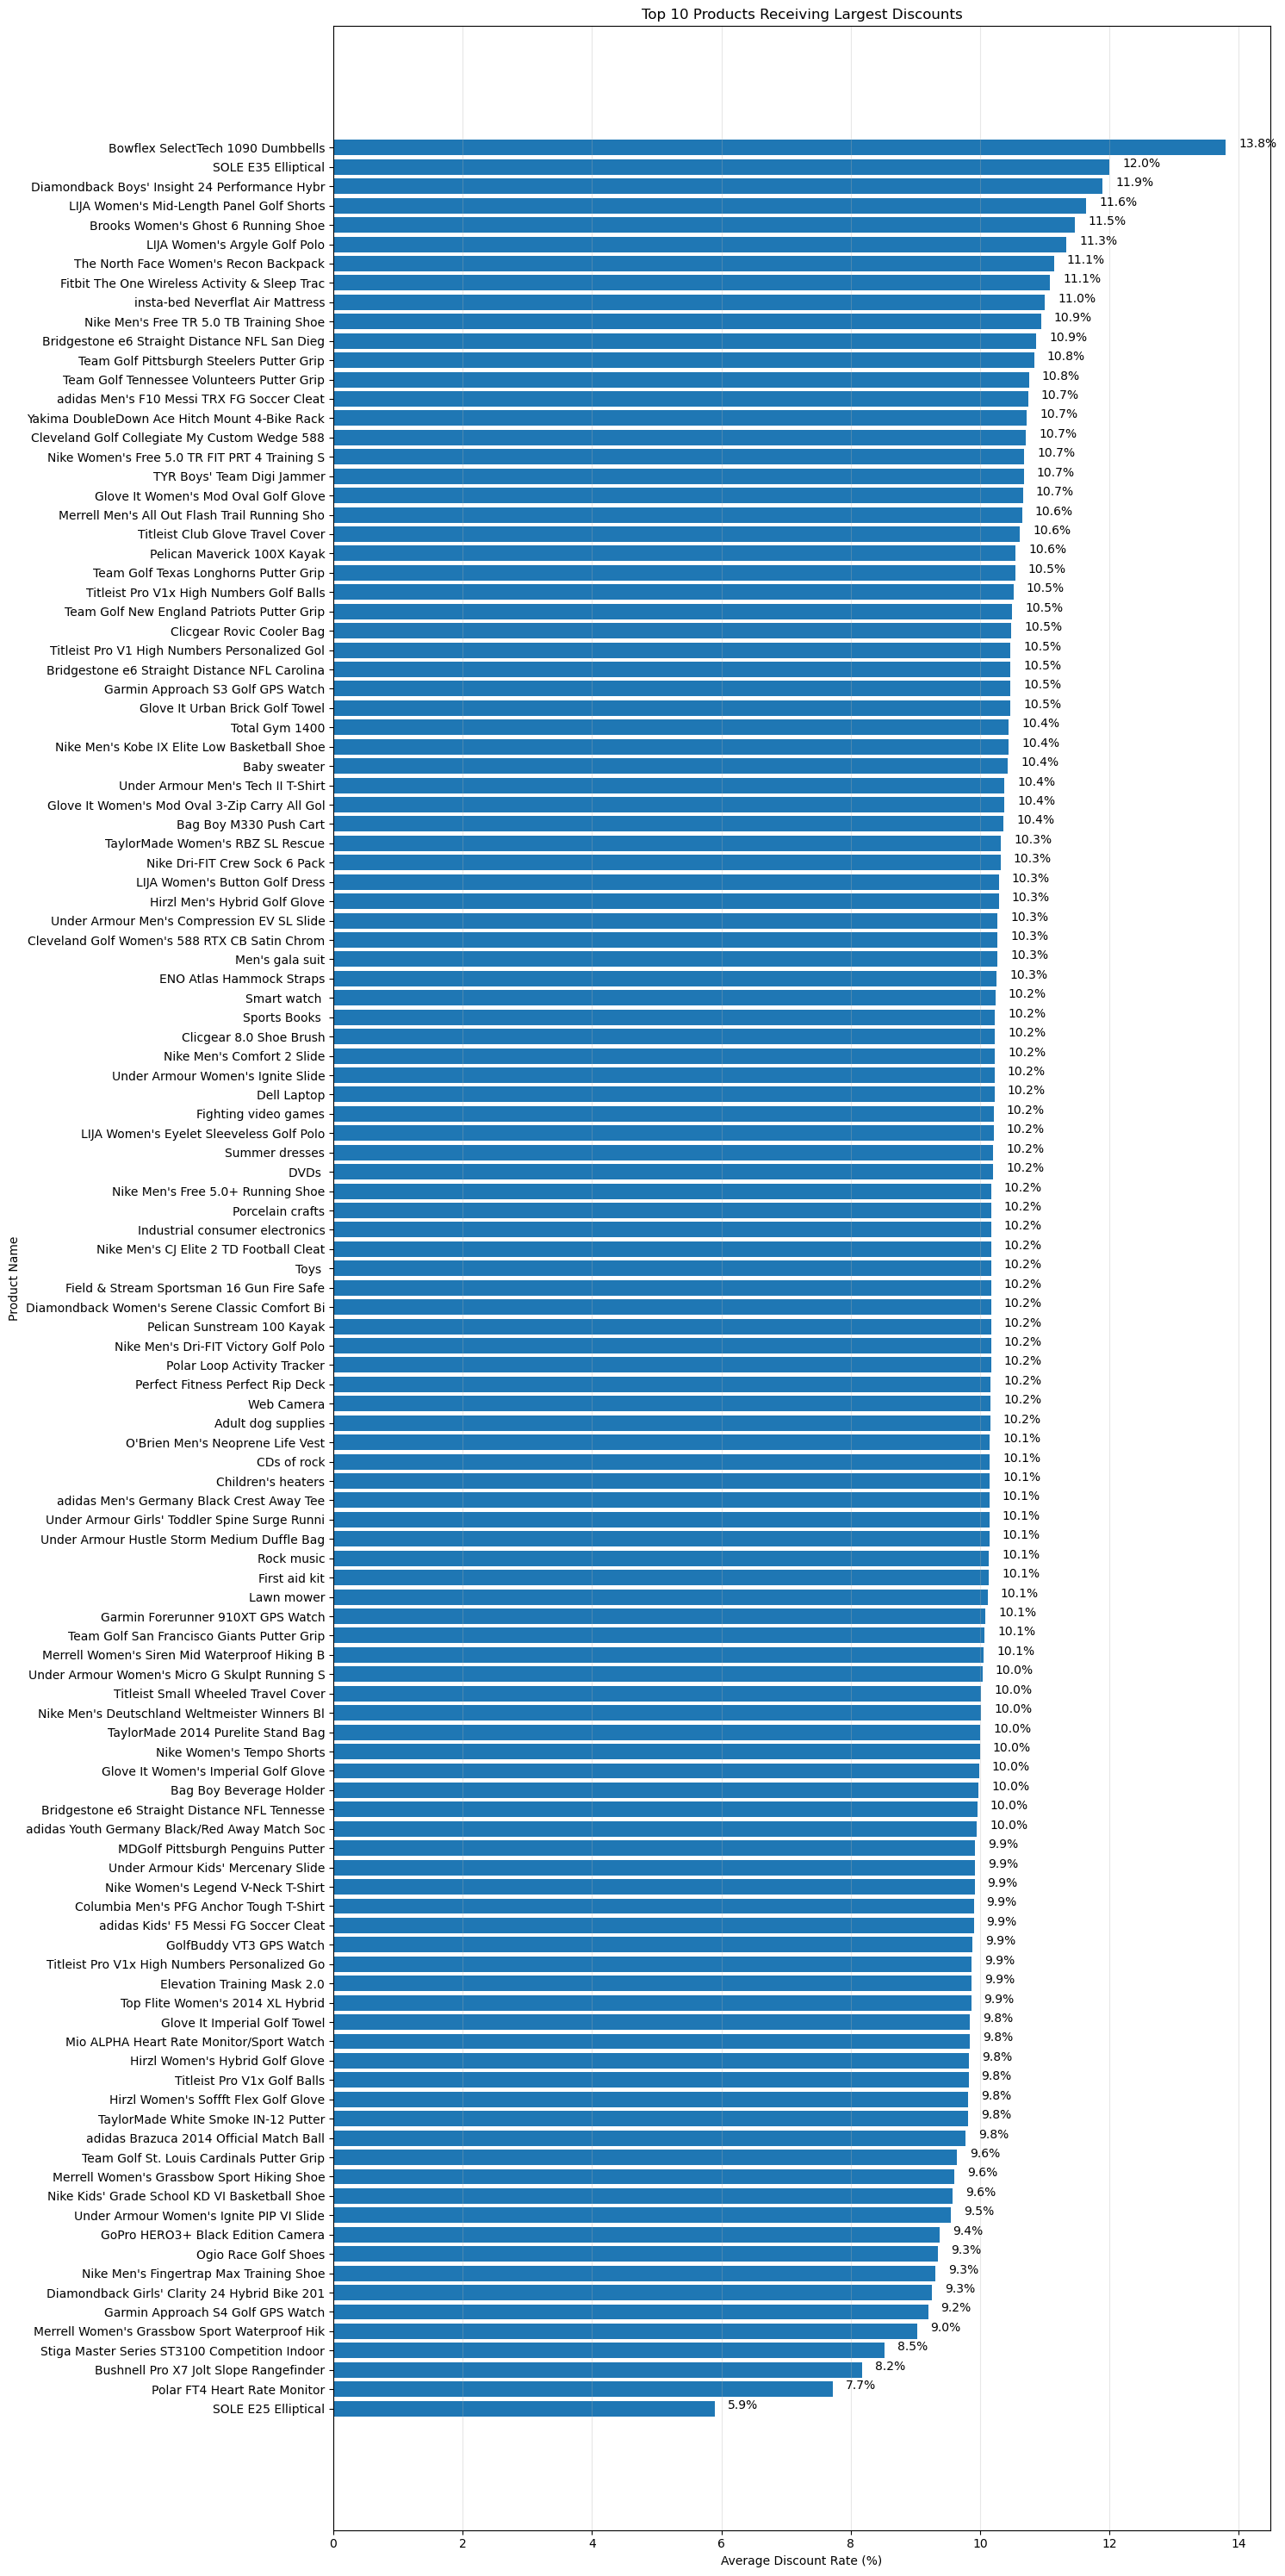

In [6]:
plt.figure(figsize=(15,30))

plt.barh(
    top_discounted_products['Product Name'],
    top_discounted_products['Order Item Discount Rate'] * 100
)
for i, value in enumerate(
    top_discounted_products['Order Item Discount Rate'] * 100
):
    plt.text(value + 0.2, i, f'{value:.1f}%')
plt.xlabel('Average Discount Rate (%)')
plt.ylabel('Product Name')
plt.title('Top 10 Products Receiving Largest Discounts')

plt.gca().invert_yaxis()  # highest on top
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
top_discounted_Category = df.groupby('Category Name')[
    'Order Item Discount Rate'
].mean().reset_index()

top_discounted_Category = top_discounted_Category.sort_values(
    by='Order Item Discount Rate',
    ascending=False
)

top_discounted_Category.head(10)

,Category Name,Order Item Discount Rate
1,As Seen on TV!,0.109412
26,Golf Shoes,0.105611
41,Strength Training,0.105045
29,Hunting & Shooting,0.104705
2,Baby,0.104300
0,Accessories,0.103831
6,Boxing & MMA,0.103664
3,Baseball & Softball,0.102943
33,Men's Clothing,0.102692
19,Fitness Accessories,0.102589


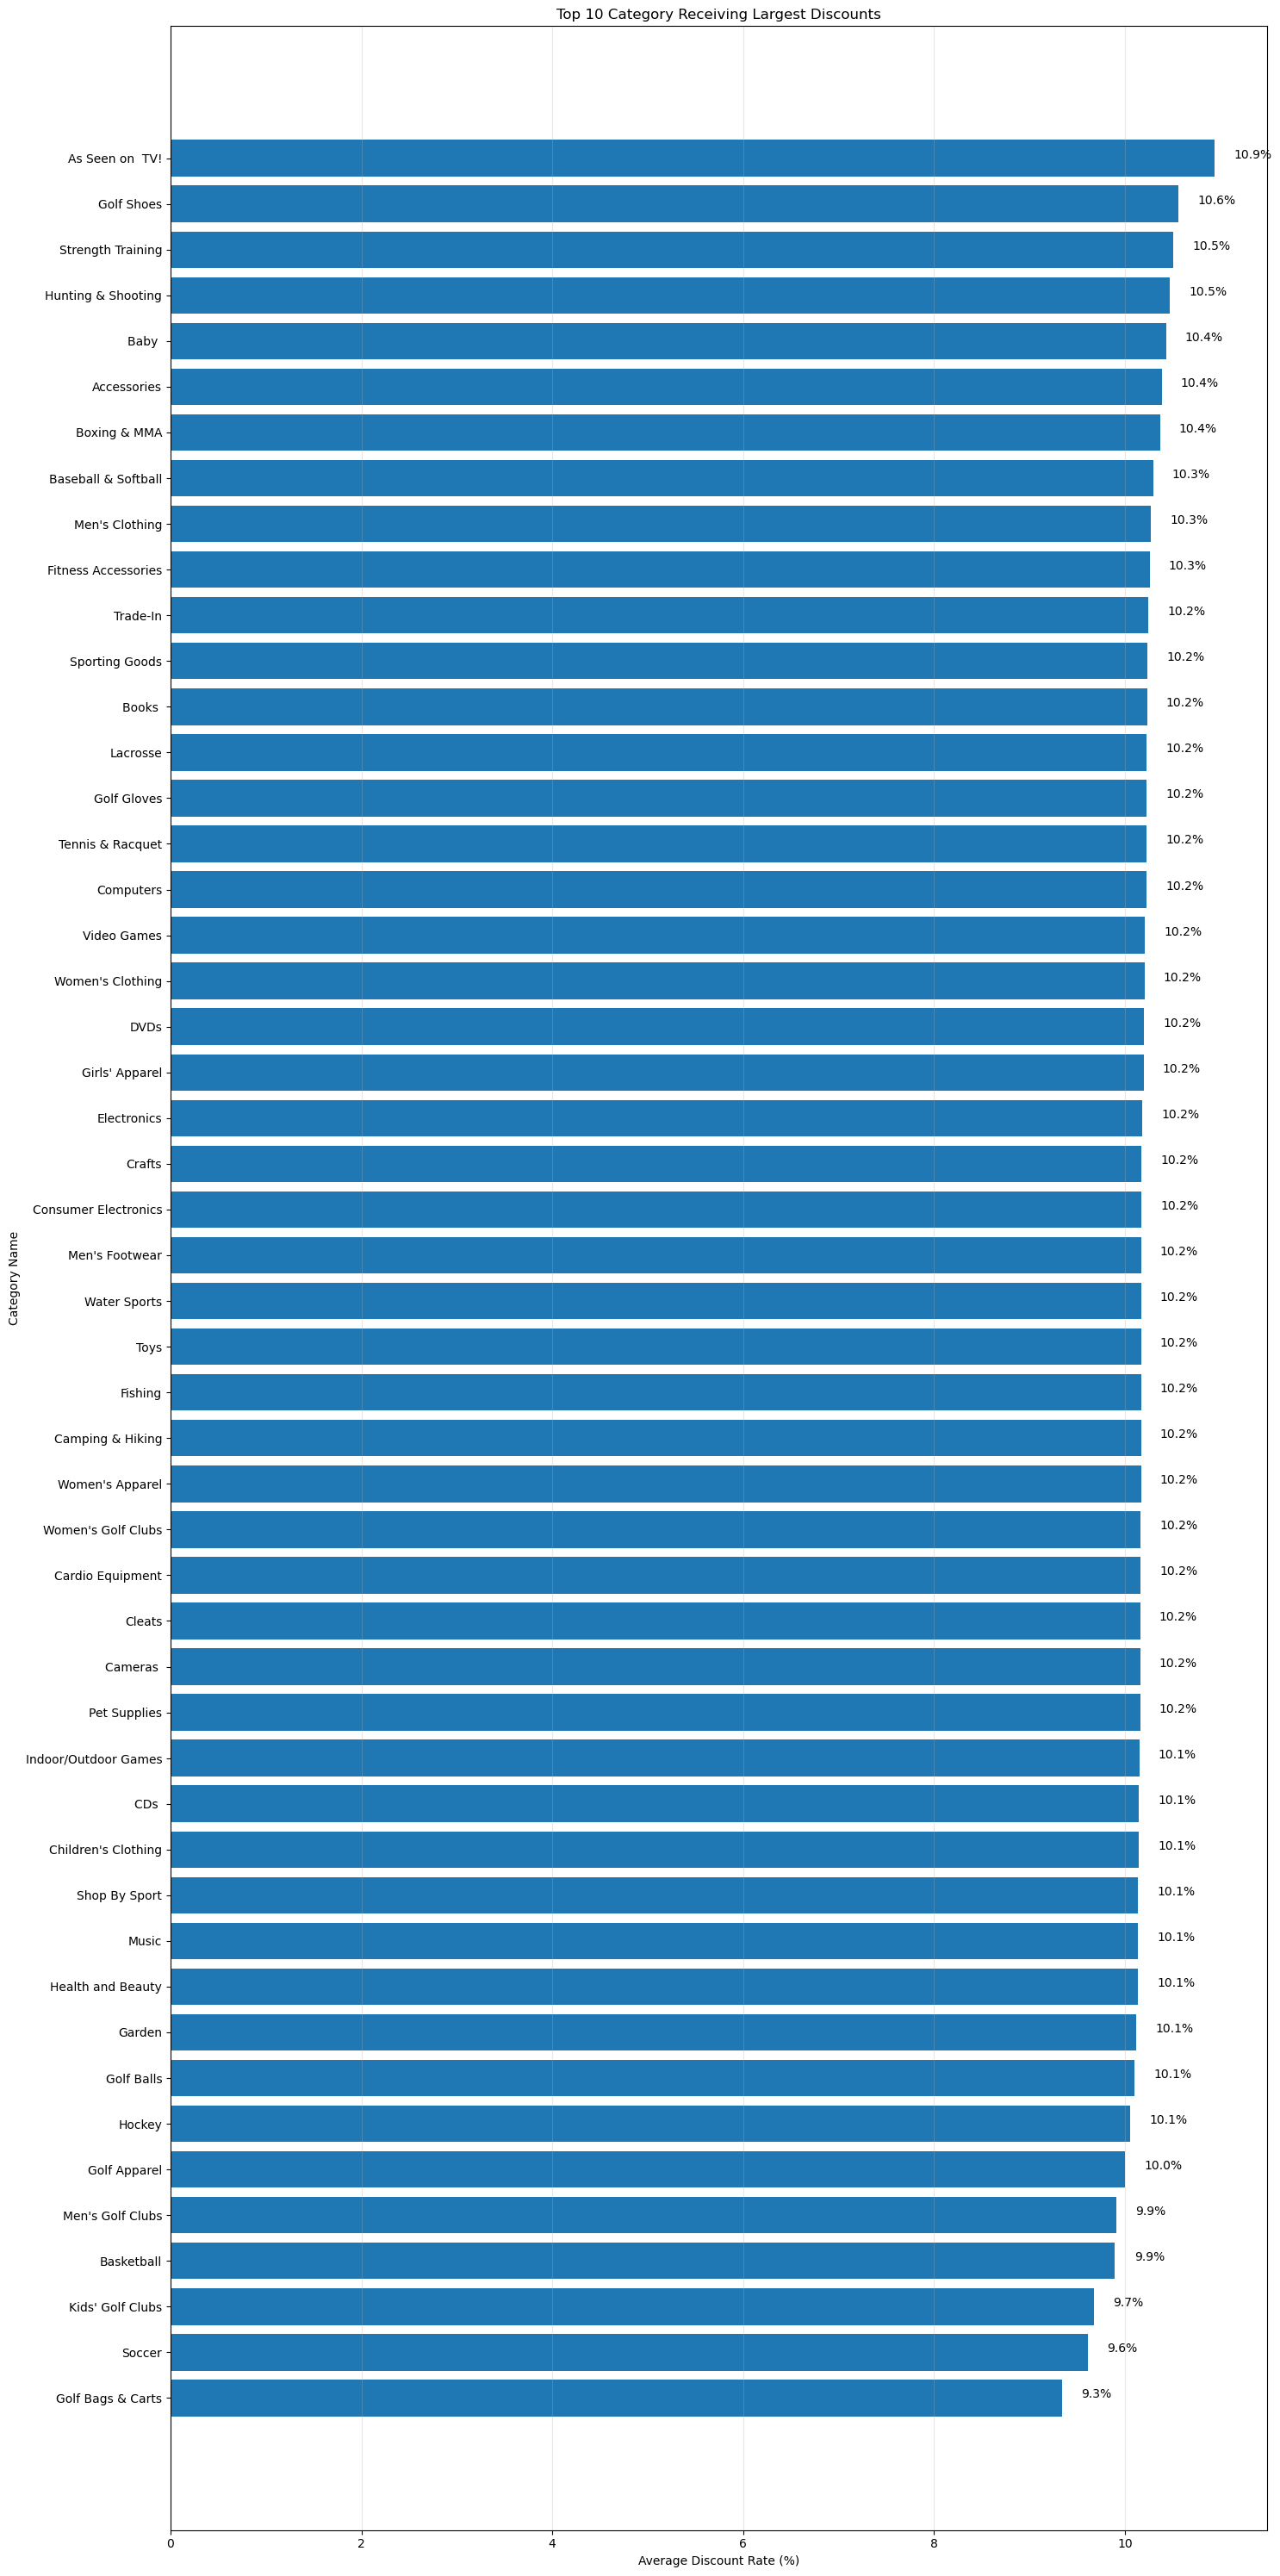

In [8]:
plt.figure(figsize=(15,30))

plt.barh(
    top_discounted_Category['Category Name'],
    top_discounted_Category['Order Item Discount Rate'] * 100
)
for i, value in enumerate(
    top_discounted_Category['Order Item Discount Rate'] * 100
):
    plt.text(value + 0.2, i, f'{value:.1f}%')
plt.xlabel('Average Discount Rate (%)')
plt.ylabel('Category Name')
plt.title('Top 10 Category Receiving Largest Discounts')

plt.gca().invert_yaxis()  # highest on top
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
product_summary = df.groupby('Product Name').agg({
    'Order Item Discount Rate': 'mean',
    'Sales': 'sum'
}).reset_index()

corr = product_summary['Order Item Discount Rate'].corr(
    product_summary['Sales']
)

print("Product-level correlation btw discount and sales:", round(corr, 3))

Product-level correlation btw discount and sales: -0.004


The correlation between discount rate and sales is -0.004, indicating virtually no linear relationship between the two variables. Based on this dataset, higher discounts do not appear to have a significant impact on sales performance.

In [10]:
corr = df['Order Item Discount Rate'].corr(df['Profit Margin']
)

print("Correlation:", round(corr, 3))

Correlation: -0.023


In [11]:
category_summary = df.groupby('Category Name').agg({
    'Order Item Discount Rate': 'mean',
    'Profit Margin': 'mean'
}).reset_index()

corr = category_summary['Order Item Discount Rate'].corr(
    category_summary['Profit Margin']
)

print("Category-level correlation:", round(corr, 3))

Category-level correlation: -0.497


In [12]:
product_level = df.groupby('Product Name').agg({
    'Order Item Discount Rate': 'mean',
    'Sales': 'sum',
    'Order Profit Per Order': 'sum'
}).reset_index()

product_level['Profit Margin'] = (
    product_level['Order Profit Per Order'] /
    product_level['Sales']
) * 100

corr = product_level['Order Item Discount Rate'].corr(
    product_level['Profit Margin']
)

print("product_level correlation:", round(corr, 3))

product_level correlation: 0.296


Correlation analysis at different aggregation levels revealed varying relationships between discount rate and profitability. At the order level, almost no relationship was observed (−0.023), suggesting transaction-level noise. At the product level, a weak positive correlation (+0.296) indicates that certain high-margin products can sustain larger discounts while remaining profitable. However, category-level analysis showed a moderate negative correlation (−0.497), implying that categories with higher average discounts generally experience reduced profitability. This demonstrates that the impact of discounting is context-dependent and varies across business segments.

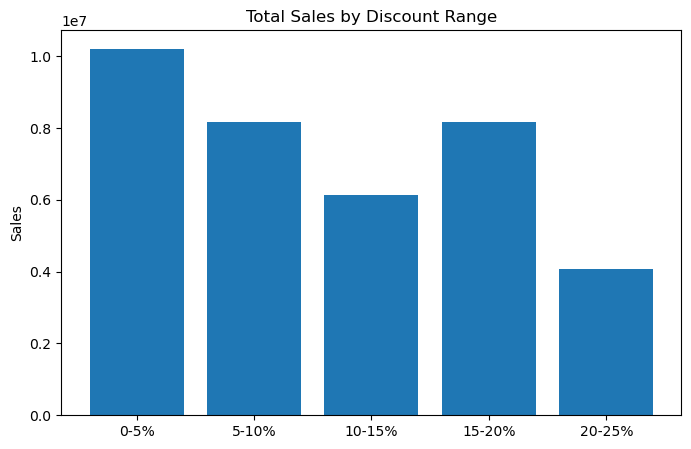

In [13]:
temp = df.copy()

temp['Discount Bin'] = pd.cut(
    temp['Order Item Discount Rate'] * 100,
    bins=[0, 5, 10, 15, 20, 25],
    labels=['0-5%', '5-10%', '10-15%', '15-20%', '20-25%'],
    include_lowest=True
)
discount_analysis = temp.groupby('Discount Bin').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Order Profit Per Order', 'sum'),
    Avg_Profit_Margin=('Profit Margin', 'mean'),
    Number_of_Orders=('Order Id', 'nunique')
).reset_index()
plt.figure(figsize=(8,5))
plt.bar(
    discount_analysis['Discount Bin'],
    discount_analysis['Total_Sales']
)

plt.title('Total Sales by Discount Range')
plt.ylabel('Sales')
plt.show()

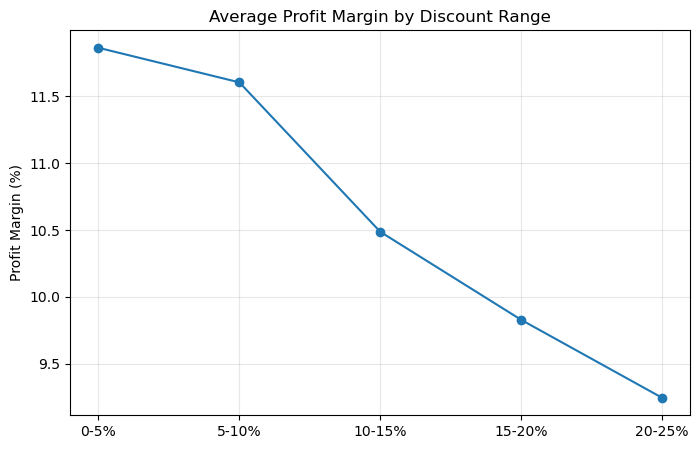

In [14]:
plt.figure(figsize=(8,5))
plt.plot(
    discount_analysis['Discount Bin'],
    discount_analysis['Avg_Profit_Margin'],
    marker='o'
)

plt.title('Average Profit Margin by Discount Range')
plt.ylabel('Profit Margin (%)')
plt.grid(alpha=0.3)
plt.show()

Discount bin analysis shows that products with lower discount ranges (0–5%) generated the highest total sales, followed by products in the 5–10% and 15–20% discount ranges. This indicates that heavy discounting does not necessarily lead to higher sales volumes. Additionally, average profit margin exhibited a steady decline as discount percentage increased, confirming that larger discounts reduce profitability. Overall, moderate or low discount strategies appear more effective, as they maintain both strong sales performance and healthier profit margins.

In [15]:
discount_analysis['Sales per Order'] = (
    discount_analysis['Total_Sales'] /
    discount_analysis['Number_of_Orders']
)
discount_analysis

,Discount Bin,Total_Sales,Total_Profit,Avg_Profit_Margin,Number_of_Orders,Sales per Order
0,0-5%,1.021470e+07,1.200626e+06,11.862610,34902,292.668102
1,5-10%,8.173765e+06,9.430585e+05,11.603920,29592,276.215350
2,10-15%,6.131173e+06,6.460825e+05,10.486139,23689,258.819401
3,15-20%,8.176531e+06,8.079262e+05,9.827701,29622,276.028994
4,20-25%,4.088565e+06,3.692095e+05,9.244685,17152,238.372471


Analysis indicates that lower discount ranges attract higher sales, with the 0–5% discount bin generating the maximum revenue. A particularly important observation is the comparison between the 5–10% and 15–20% discount bins. Both bins show nearly identical total sales, number of orders, and sales per order, yet the 15–20% discount range exhibits a significantly lower profit margin (9.83% vs 11.60%). This suggests that discounts beyond approximately 10% do not provide meaningful sales gains and instead reduce profitability, indicating diminishing returns from aggressive discounting.

In [16]:
loss_products = df.groupby('Product Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Order Profit Per Order', 'sum'),
    Avg_Discount=('Order Item Discount Rate', 'mean')
).reset_index()
loss_products['Profit Margin'] = (
    loss_products['Total_Profit'] / loss_products['Total_Sales']
) * 100

loss_products = loss_products[
    loss_products['Total_Profit'] < 0
].sort_values(by='Total_Profit')

loss_products.head(20)

,Product Name,Total_Sales,Total_Profit,Avg_Discount,Profit Margin
77,SOLE E35 Elliptical,29999.849850,-965.119968,0.120000,-3.217083
9,Bushnell Pro X7 Jolt Slope Rangefinder,6599.889892,-255.950003,0.081818,-3.878095
76,SOLE E25 Elliptical,9999.899902,-169.559997,0.059000,-1.695617


In [17]:
temp = df.copy()

temp['Sales Before Discount'] = (
    temp['Sales'] / (1 - temp['Order Item Discount Rate'])
)

temp['Discount Loss'] = (
    temp['Sales Before Discount'] - temp['Sales']
)

temp['Profit Without Discount'] = (
    temp['Order Profit Per Order'] + temp['Discount Loss']
)

profit_compare = temp.groupby('Product Name').agg(
    Total_Sales=('Sales', 'sum'),
    Avg_Discount=('Order Item Discount Rate', 'mean'),
    Profit_After_Discount=('Order Profit Per Order', 'sum'),
    Profit_Without_Discount=('Profit Without Discount', 'sum')
).reset_index()

profit_compare['Profit Margin After'] = (
    profit_compare['Profit_After_Discount'] /
    profit_compare['Total_Sales']
) * 100

profit_compare['Profit Margin Without'] = (
    profit_compare['Profit_Without_Discount'] /
    profit_compare['Total_Sales']
) * 100


profit_compare['Profit Lost Due to Discount'] = (
    profit_compare['Profit_Without_Discount'] -
    profit_compare['Profit_After_Discount']
)

discount_caused_losses = profit_compare[
    (profit_compare['Profit_After_Discount'] < 0) &
    (profit_compare['Profit_Without_Discount'] > 0)
].sort_values(
    by='Profit_After_Discount'
)

print("Products that became loss-making  discount:")
display(discount_caused_losses)

profit_compare_sorted = profit_compare.sort_values(
    by='Profit Lost Due to Discount',
    ascending=False
)

display(profit_compare_sorted.head(20))

Products that became loss-making  discount:


,Product Name,Total_Sales,Avg_Discount,Profit_After_Discount,Profit_Without_Discount,Profit Margin After,Profit Margin Without,Profit Lost Due to Discount
77,SOLE E35 Elliptical,29999.849850,0.120000,-965.119968,3304.333497,-3.217083,11.014500,4269.453466
9,Bushnell Pro X7 Jolt Slope Rangefinder,6599.889892,0.081818,-255.950003,362.475074,-3.878095,5.492138,618.425077
76,SOLE E25 Elliptical,9999.899902,0.059000,-169.559997,471.643289,-1.695617,4.716480,641.203286


,Product Name,Total_Sales,Avg_Discount,Profit_After_Discount,Profit_Without_Discount,Profit Margin After,Profit Margin Without,Profit Lost Due to Discount
24,Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,0.101681,756220.767190,1.589911e+06,10.912822,22.943584,833690.163657
71,Perfect Fitness Perfect Rip Deck,4.421143e+06,0.101590,493828.299782,1.025264e+06,11.169697,23.190024,531435.853262
21,Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,0.101681,427455.568106,9.229291e+05,10.379101,22.409755,495473.497871
61,Nike Men's Free 5.0+ Running Shoe,3.667633e+06,0.101695,379915.818503,8.213209e+05,10.358610,22.393759,441405.112098
59,Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,0.101669,350421.029567,7.289571e+05,11.132252,23.157669,378536.085975
70,Pelican Sunstream 100 Kayak,3.099845e+06,0.101674,324076.370020,6.970035e+05,10.454599,22.485108,372927.152822
56,Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06,0.101683,311902.820214,6.598192e+05,10.785925,22.817238,347916.408395
67,O'Brien Men's Neoprene Life Vest,2.888994e+06,0.101493,318451.430554,6.654414e+05,11.022918,23.033672,346989.962312
102,Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06,0.101411,126278.510299,2.784703e+05,9.950377,21.942646,152191.810397
18,Dell Laptop,6.630000e+05,0.102240,69656.810171,1.499375e+05,10.506306,22.615009,80280.696348


# Customer Behavior


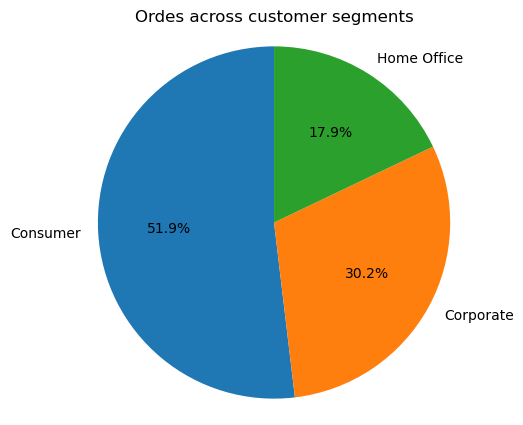

In [18]:
plt.figure(figsize=(5,5))
total_order_percus = df.groupby('Customer Segment')['Order Id'].nunique()
plt.pie(total_order_percus.values,labels=total_order_percus.index,autopct='%1.1f%%',startangle=90)

plt.title('Ordes across customer segments')
plt.axis('equal')  
plt.show()

In [19]:
print("Orders per segment:")
print(total_order_percus)

print("\nSegment with most orders:")
print(total_order_percus.idxmax())
print("Number of orders:", total_order_percus.max())

Orders per segment:
Customer Segment
Consumer       34119
Corporate      19856
Home Office    11777
Name: Order Id, dtype: int64

Segment with most orders:
Consumer
Number of orders: 34119


In [20]:
total_Sales_percus_amount = df.groupby('Customer Segment')['Sales'].sum()
print(total_Sales_percus_amount.sort_values(ascending=False))
print("\nSegment with most Sales:")
print(total_Sales_percus_amount.idxmax())

Customer Segment
Consumer       1.909579e+07
Corporate      1.116841e+07
Home Office    6.520538e+06
Name: Sales, dtype: float64

Segment with most Sales:
Consumer


In [21]:
total_Profit_percus_amount = df.groupby('Customer Segment')['Order Profit Per Order'].sum()
print(total_Profit_percus_amount.sort_values(ascending=False))
print("\nSegment with most Profit:")
print(total_Profit_percus_amount.idxmax())

Customer Segment
Consumer       2.073488e+06
Corporate      1.202575e+06
Home Office    6.908403e+05
Name: Order Profit Per Order, dtype: float64

Segment with most Profit:
Consumer


In [30]:
top_customers_rev = (df.groupby(['Customer Id','Customer Fname','Customer Lname'])['Sales'].sum().sort_values(ascending=False))
top_customers_rev.head(10)

Customer Id  Customer Fname  Customer Lname
791          Mary            Smith             10524.170178
9371         Mary            Patterson          9299.030207
8766         Mary            Duncan             9296.140186
1657         Betty           Phillips           9223.710152
2641         Betty           Spears             9130.920224
1288         Evelyn          Thompson           9019.110199
3710         Ashley          Smith              9019.100208
4249         Mary            Butler             8918.850134
5654         Jerry           Smith              8904.950211
5624         Mary            Mata               8761.980183
Name: Sales, dtype: float64

In [23]:
top_customers_profit = (df.groupby(['Customer Id','Customer Fname','Customer Lname'])['Order Profit Per Order'].sum().sort_values(ascending=False))
top_customers_profit.head(10)

Customer Id  Customer Fname  Customer Lname
2641         Betty           Spears            2441.970003
1657         Betty           Phillips          2196.919992
9833         Jacob           Smith             1938.390015
2626         Laura           Smith             1928.570015
5004         Dorothy         Friedman          1917.990002
3735         Mary            Lewis             1906.360009
749          Jesse           Matthews          1855.149989
5560         Mary            Rodriguez         1831.460010
10967        Alexander       Cunningham        1822.330006
5053         Mary            Smith             1813.339999
Name: Order Profit Per Order, dtype: float64

In [24]:
customer_con_city = (df.groupby(['Customer City'])['Customer Id'].nunique().sort_values(ascending=False))
customer_con_city.head(10)

Customer City
Caguas          7652
Chicago          435
Los Angeles      393
Brooklyn         375
New York         194
Bronx            173
Philadelphia     164
San Diego        154
Houston          148
Miami            138
Name: Customer Id, dtype: int64

In [25]:
customer_con_Country = (df.groupby(['Customer Country'])['Customer Id'].nunique().sort_values(ascending=False))
customer_con_Country.head(10)

Customer Country
EE. UU.        12719
Puerto Rico     7933
Name: Customer Id, dtype: int64

# Product Portfolio

In [29]:
freq_purchased = df.groupby(['Product Name'])['Order Item Id'].nunique().sort_values(ascending=False)
freq_purchased

Product Name
Perfect Fitness Perfect Rip Deck                 24515
Nike Men's CJ Elite 2 TD Football Cleat          22246
Nike Men's Dri-FIT Victory Golf Polo             21035
O'Brien Men's Neoprene Life Vest                 19298
Field & Stream Sportsman 16 Gun Fire Safe        17325
                                                 ...  
Stiga Master Series ST3100 Competition Indoor       27
SOLE E35 Elliptical                                 15
Bushnell Pro X7 Jolt Slope Rangefinder              11
SOLE E25 Elliptical                                 10
Bowflex SelectTech 1090 Dumbbells                   10
Name: Order Item Id, Length: 118, dtype: int64

In [31]:
top_revenue_products = (df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False))
top_revenue_products.head(20)

Product Name
Field & Stream Sportsman 16 Gun Fire Safe        6.929654e+06
Perfect Fitness Perfect Rip Deck                 4.421143e+06
Diamondback Women's Serene Classic Comfort Bi    4.118426e+06
Nike Men's Free 5.0+ Running Shoe                3.667633e+06
Nike Men's Dri-FIT Victory Golf Polo             3.147800e+06
Pelican Sunstream 100 Kayak                      3.099845e+06
Nike Men's CJ Elite 2 TD Football Cleat          2.891758e+06
O'Brien Men's Neoprene Life Vest                 2.888994e+06
Under Armour Girls' Toddler Spine Surge Runni    1.269083e+06
Dell Laptop                                      6.630000e+05
Web Camera                                       2.676077e+05
Lawn mower                                       2.577687e+05
Children's heaters                               2.328292e+05
Porcelain crafts                                 2.233563e+05
Summer dresses                                   1.402830e+05
Smart watch                                      1.170068

In [32]:
top_profit_products = (df.groupby('Product Name')['Order Profit Per Order'].sum().sort_values(ascending=False))
top_profit_products.head(20)

Product Name
Field & Stream Sportsman 16 Gun Fire Safe        756220.767190
Perfect Fitness Perfect Rip Deck                 493828.299782
Diamondback Women's Serene Classic Comfort Bi    427455.568106
Nike Men's Free 5.0+ Running Shoe                379915.818503
Nike Men's Dri-FIT Victory Golf Polo             350421.029567
Pelican Sunstream 100 Kayak                      324076.370020
O'Brien Men's Neoprene Life Vest                 318451.430554
Nike Men's CJ Elite 2 TD Football Cleat          311902.820214
Under Armour Girls' Toddler Spine Surge Runni    126278.510299
Dell Laptop                                       69656.810171
Lawn mower                                        33443.010106
Web Camera                                        30289.799946
Children's heaters                                27178.099597
Porcelain crafts                                  25531.170060
Summer dresses                                    19102.849930
Rock music                                

In [34]:
top_profit_products.tail(20)

Product Name
Titleist Small Wheeled Travel Cover              1011.650054
Cleveland Golf Collegiate My Custom Wedge 588     955.099942
Toys                                              900.710000
Sports Books                                      883.010008
Clicgear 8.0 Shoe Brush                           815.540004
Total Gym 1400                                    808.620008
TaylorMade 2014 Purelite Stand Bag                730.180011
Nike Men's Free TR 5.0 TB Training Shoe           714.429980
Nike Men's Fingertrap Max Training Shoe           602.379973
GolfBuddy VT3 GPS Watch                           569.020010
Stiga Master Series ST3100 Competition Indoor     479.280016
Garmin Forerunner 910XT GPS Watch                 391.129990
CDs of rock                                       383.850000
Cleveland Golf Women's 588 RTX CB Satin Chrom     370.610006
Polar Loop Activity Tracker                       326.200001
Diamondback Girls' Clarity 24 Hybrid Bike 201     284.420003
GoPro HERO3

In [35]:
cat_sales = (df.groupby('Category Name')['Sales'].sum().sort_values(ascending=False))
cat_sales.head(20)

Category Name
Fishing                 6.929654e+06
Cleats                  4.431943e+06
Camping & Hiking        4.118426e+06
Cardio Equipment        3.694843e+06
Women's Apparel         3.147800e+06
Water Sports            3.113845e+06
Men's Footwear          2.891758e+06
Indoor/Outdoor Games    2.888994e+06
Shop By Sport           1.309522e+06
Computers               6.630000e+05
Electronics             3.710346e+05
Cameras                 2.676077e+05
Garden                  2.577687e+05
Children's Clothing     2.328292e+05
Crafts                  2.233563e+05
Girls' Apparel          1.517062e+05
Women's Clothing        1.402830e+05
Accessories             1.336715e+05
Sporting Goods          1.170068e+05
Golf Gloves             1.166954e+05
Name: Sales, dtype: float64

In [36]:
cat_profit = (df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False))
cat_profit.head(20)

Category Name
Fishing                 756220.767190
Cleats                  494636.919791
Camping & Hiking        427455.568106
Cardio Equipment        383011.098485
Women's Apparel         350421.029567
Water Sports            325146.960038
Indoor/Outdoor Games    318451.430554
Men's Footwear          311902.820214
Shop By Sport           129813.960315
Computers                69656.810171
Electronics              40891.379918
Garden                   33443.010106
Cameras                  30289.799946
Children's Clothing      27178.099597
Crafts                   25531.170060
Women's Clothing         19102.849930
Girls' Apparel           17288.569973
Accessories              16643.520074
Music                    14436.319923
Consumer Electronics     13223.399926
Name: Order Profit Per Order, dtype: float64

In [40]:
product_analysis = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Order Profit Per Order': 'sum',
    'Order Item Id': 'nunique'
})

product_analysis.columns = ['Total_Sales', 'Total_Profit', 'Orders']
product_analysis['Avg_Price'] = (product_analysis['Total_Sales'] /product_analysis['Orders'])
correlation = product_analysis['Avg_Price'].corr(product_analysis['Total_Profit'])

correlation

0.06030258106460508

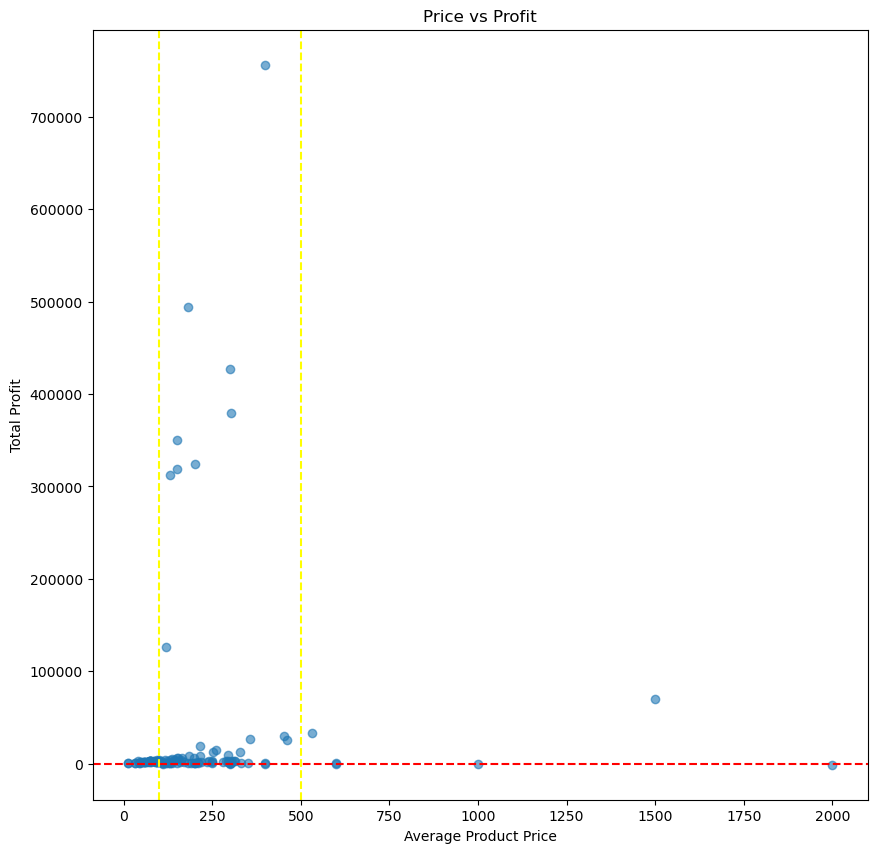

In [52]:
plt.figure(figsize=(10,10))
plt.scatter(
    product_analysis['Avg_Price'],
    product_analysis['Total_Profit'],
    alpha=0.6
)
plt.axhline(y=0, color='red', linestyle='--')
plt.axvline(x=500, color='yellow', linestyle='--')
plt.axvline(x=100, color='yellow', linestyle='--')
plt.xlabel("Average Product Price")
plt.ylabel("Total Profit")
plt.title("Price vs Profit")
plt.show()

The scatter plot between average product price and total profit indicates that higher-priced (premium) products are not necessarily more profitable. Most of the highly profitable products lie in the mid-price range (approximately $100–$500), while several premium-priced products above $1000 generate relatively low profits. This suggests that profitability depends more on factors such as sales volume, demand, and profit margin rather than product price alone.

In [62]:
price_demand = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Order Item Id': 'nunique'
})

price_demand.columns = ['Total_Sales', 'Demand']

price_demand['Avg_Price'] = (
    price_demand['Total_Sales'] / price_demand['Demand']
)
price_demand.sort_values(by='Avg_Price',ascending=True,inplace=True)
price_demand.head(10)

,Total_Sales,Demand,Avg_Price
Product Name,,,
CDs of rock,3059.589989,271,11.290000
Toys,6104.659979,529,11.540000
Sports Books,12587.399968,405,31.080000
Clicgear 8.0 Shoe Brush,8871.119937,285,31.126737
Fighting video games,33310.500000,838,39.750000
Hirzl Women's Hybrid Golf Glove,13311.119814,311,42.801028
Hirzl Men's Hybrid Golf Glove,12951.359808,282,45.926808
Glove It Urban Brick Golf Towel,14151.149793,300,47.170499
Glove It Imperial Golf Towel,14870.699789,302,49.240728


In [55]:
corr = price_demand['Avg_Price'].corr(price_demand['Demand'])
print(corr)

-0.018917133544102453


The correlation between average product price and demand was found to be −0.019, indicating a negligible negative relationship. This suggests that product price has minimal influence on customer demand in the dataset. Both low-priced and premium-priced products exhibited varying demand levels, implying that factors such as product category, brand value, and market preferences play a more significant role in determining demand than price alone